# 🌸 Project Overview: Iris Flower Classification

## 🎯 Objective

The objective of this project is to build a **machine learning classification model** that predicts the species of an iris flower based on its physical measurements.

The three target species are:

- **Setosa**
- **Versicolor**
- **Virginica**

## 📊 Dataset

The **Iris dataset** is provided directly by **scikit-learn** using the `load_iris()` function.

The dataset contains measurements of iris flowers, including:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

## 🤖 Machine Learning Models

Three classification algorithms will be trained and compared:

1. **Logistic Regression**
2. **K-Nearest Neighbors (KNN)**
3. **Decision Tree**

## 📈 Evaluation Metrics

The models will be evaluated using the following metrics:

- **Accuracy** – Measures the overall percentage of correct predictions.
- **Precision** – Measures how many predicted samples belong to the correct class.
- **Recall** – Measures how many actual samples of a class were correctly identified.
- **F1-score** – Combines precision and recall into a single metric.
- **Confusion Matrix** – Shows the number of correct and incorrect predictions for each class.

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

### 📚 Libraries and Functions Used

| Library / Function | Purpose |
|---|---|
| **pandas** | Data manipulation and analysis |
| **numpy** | Numerical operations and calculations |
| **matplotlib** | Data visualization |
| **seaborn** | Statistical data visualization |
| **load_iris** | Load the Iris dataset |
| **train_test_split** | Split the dataset into training and testing sets |
| **StandardScaler** | Scale features to a standard range |
| **LogisticRegression** | Classification model #1 |
| **KNeighborsClassifier** | Classification model #2 |
| **accuracy_score** | Calculate the accuracy of the models |
| **confusion_matrix** | Evaluate predictions using a confusion matrix |
| **classification_report** | Calculate precision, recall, and F1-score |

# Load the Iris Dataset

In [ ]:
iris = load_iris()

In [ ]:
print(iris)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [ ]:
print(iris.keys()) # Print the keys (attributes) available in the iris dictionary

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [ ]:
iris.data # Print the feature data (measurements)

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [ ]:
iris.target_names # Access the actual species names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
iris.target # Values are encoded as integers: 0 = setosa, 1 = versicolor, 2 = virginica

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
iris.DESCR # Access the full text description of the dataset

'.. _iris_dataset:\n\nIris plants dataset\n--------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 150 (50 in each of three classes)\n:Number of Attributes: 4 numeric, predictive attributes and the class\n:Attribute Information:\n    - sepal length in cm\n    - sepal width in cm\n    - petal length in cm\n    - petal width in cm\n    - class:\n            - Iris-Setosa\n            - Iris-Versicolour\n            - Iris-Virginica\n\n:Summary Statistics:\n\n============== ==== ==== ======= ===== ====================\n                Min  Max   Mean    SD   Class Correlation\n============== ==== ==== ======= ===== ====================\nsepal length:   4.3  7.9   5.84   0.83    0.7826\nsepal width:    2.0  4.4   3.05   0.43   -0.4194\npetal length:   1.0  6.9   3.76   1.76    0.9490  (high!)\npetal width:    0.1  2.5   1.20   0.76    0.9565  (high!)\n============== ==== ==== ======= ===== ====================\n\n:Missing Attribute Values: None\n:Class Distribution: 

In [ ]:
iris.feature_names # Print the names of the features

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [ ]:
iris.filename # Print name of dataset file

'iris.csv'

In [ ]:
iris.data_module # Access the internal scikit-learn module path where this dataset's file is stored

'sklearn.datasets.data'

In [ ]:
iris.frame # Return the dataset as a pandas DataFrame (combining data + target)

In [ ]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [ ]:
# Reload the dataset, but this time return it as a pandas DataFrame
# This will make iris.frame contain a DataFrame combining data + target
iris = load_iris(as_frame=True)

iris.frame

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


## Load the Iris Dataset Summary

In this section, we load the **Iris dataset** from `sklearn.datasets` and explore its structure.

- `load_iris()` returns a **Bunch** object (dictionary-like) containing the data and metadata.
- **`iris.data`**: NumPy array of shape `(150, 4)` — the 4 numeric features (sepal length, sepal width, petal length, petal width) for 150 flower samples.
- **`iris.target`**: NumPy array of shape `(150,)` — the class label (0, 1, or 2) for each sample.
- **`iris.target_names`**: The actual species names — `['setosa', 'versicolor', 'virginica']`.
- **`iris.feature_names`**: The names of the 4 features.
- **`iris.DESCR`**: A full text description of the dataset (source, statistics, references).
- **`iris.filename`** / **`iris.data_module`**: Internal references to the source file/module.
- **`iris.frame`**: `None` by default; returns a combined pandas DataFrame if loaded with `as_frame=True`.

The dataset contains **150 samples**, evenly split into **3 classes** (50 each).

# Exploratory Data Analysis (EDA) & Understand the Features

In [ ]:
pd.set_option('display.max_columns', None) # Display all columns
pd.set_option('display.max_rows', None)    # Display all rows

In [ ]:
df = pd.DataFrame(iris.data, columns=iris.feature_names) # Convert to a DataFrame
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names) # Create target column named ('species')
df.head(150) # Display first 150 rows (all the dataset)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [ ]:
df.shape # Check the shape of the DataFrame (rows, columns)

(150, 6)

In [ ]:
df.info() # Check basic information about the data like (data types, non-null, counts,......)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB


In [ ]:
df.isnull().sum() # Number of missing values

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [ ]:
df.describe() # Get summary statistics (mean, std, min, max, quartiles)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
df['species'].value_counts() # Check class distribution (how many samples per species)

,count
species,
setosa,50
versicolor,50
virginica,50


In [ ]:
df.corr(numeric_only=True) # Check feature correlations

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


In [ ]:
df["target"] = iris.target # Create target numeric column
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,target
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0


In [ ]:
df.corr(numeric_only=True) # Check feature correlations

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


## EDA Summary

Before building any model, it's important to explore and understand the dataset's structure and characteristics.

- Converted the `iris` Bunch object into a **pandas DataFrame** for easier exploration, adding a `species` column mapped from the numeric `target` values.
- Used `df.head()` to preview the rows and get a feel for the actual data values.
- Used `df.info()` to confirm the data types of each column and check for unexpected non-null issues.
- Used `df.isnull().sum()` to verify there are **no missing values** in the dataset.
- Used `df.describe()` to review summary statistics (mean, std, min, max, quartiles) for each numeric feature.
- Used `df['species'].value_counts()` to confirm the dataset is **perfectly balanced**, with 50 samples per species.
- Used `df.corr()` to examine correlations between features, revealing that **petal length and petal width** are very strongly correlated with each other and with the target class.
- The features have different ranges, which may be relevant for distance-based
  algorithms such as KNN.

# Visualization

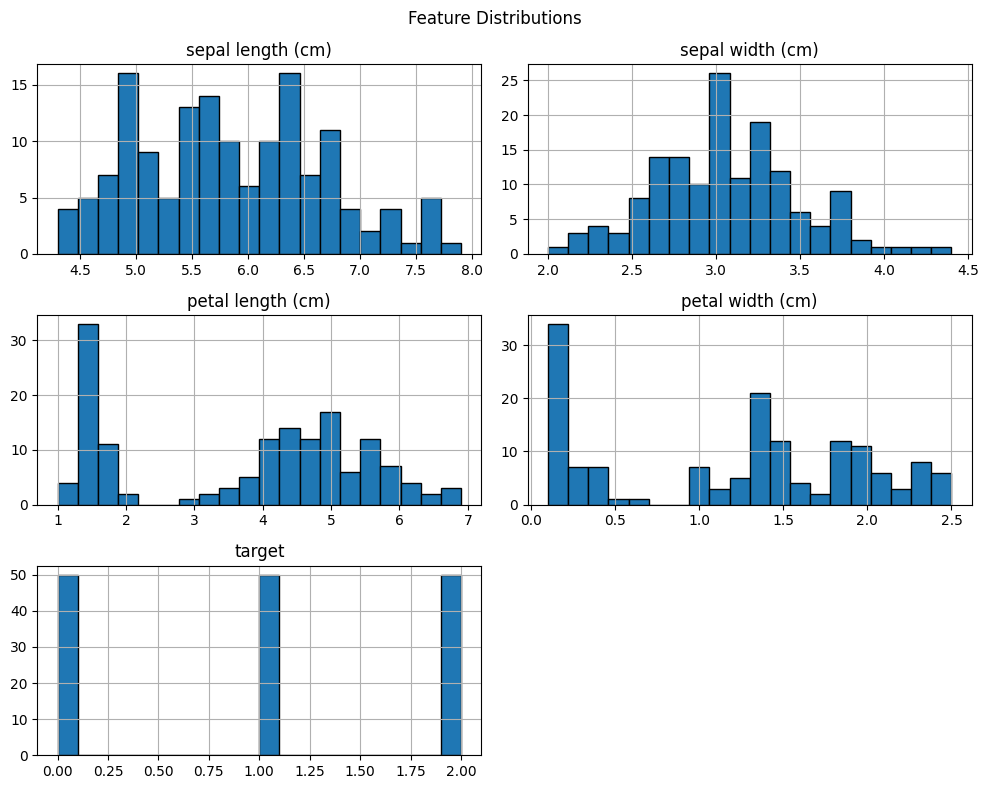

In [ ]:
# Feature Distributions
df.hist(figsize=(10, 8), bins=20, edgecolor='black')
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

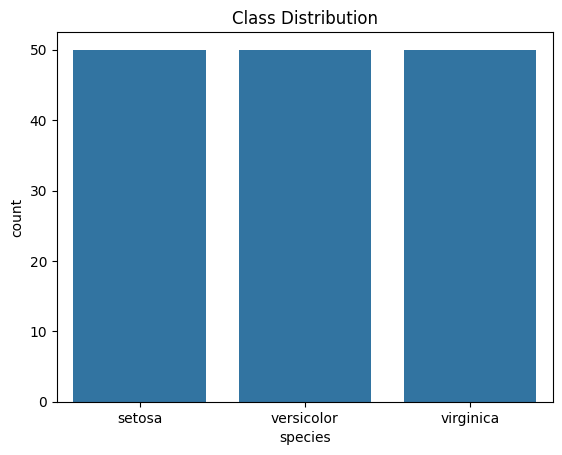

In [ ]:
# Class Distribution
sns.countplot(data=df, x='species')
plt.title('Class Distribution')
plt.show()

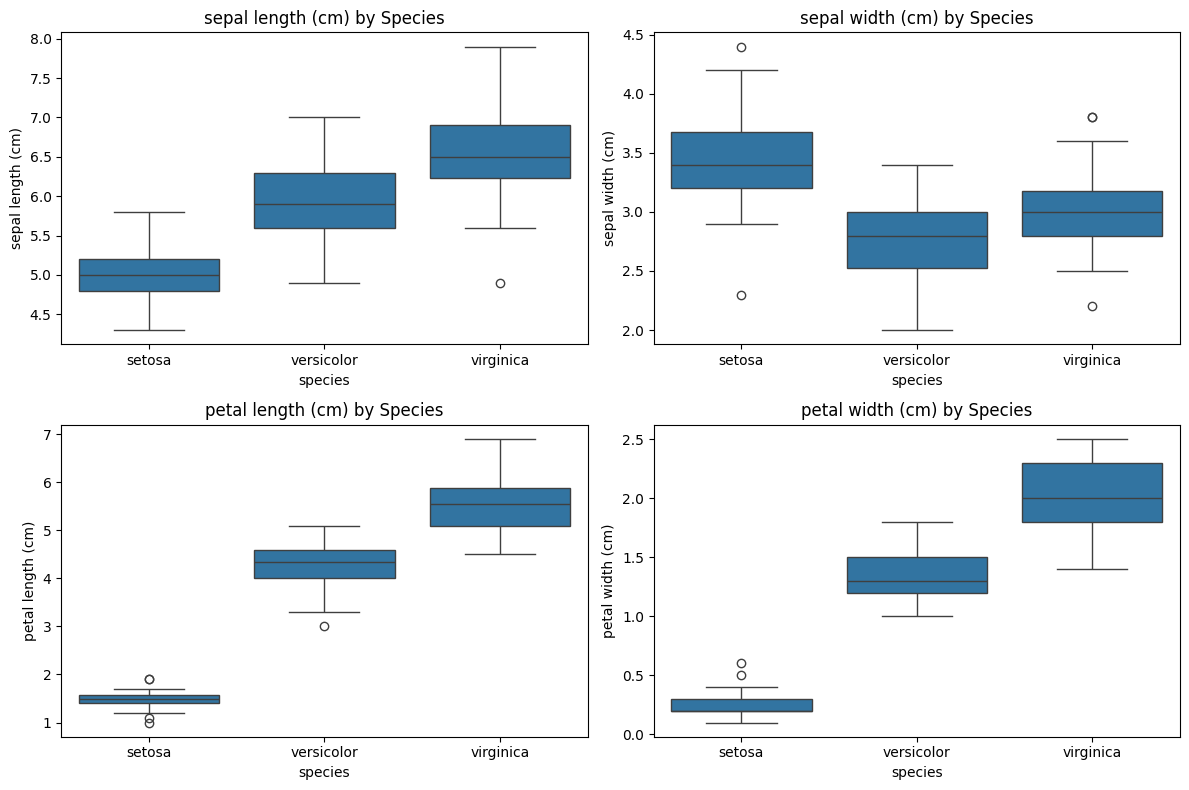

In [ ]:
# Boxplots by Species
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feature in zip(axes.flatten(), iris.feature_names):
    sns.boxplot(data=df, x='species', y=feature, ax=ax)
    ax.set_title(f'{feature} by Species')
plt.tight_layout()
plt.show()

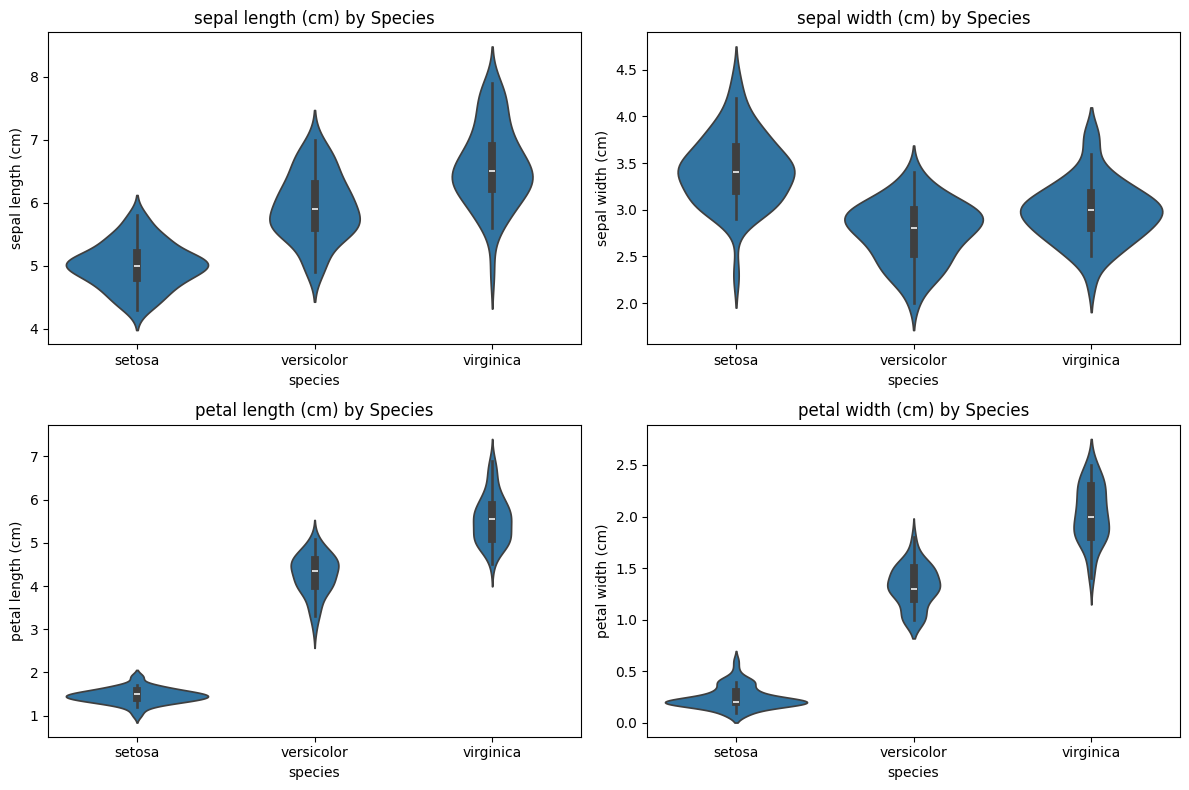

In [ ]:
# Violin Plots by Species
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feature in zip(axes.flatten(), iris.feature_names):
    sns.violinplot(data=df, x='species', y=feature, ax=ax)
    ax.set_title(f'{feature} by Species')
plt.tight_layout()
plt.show()

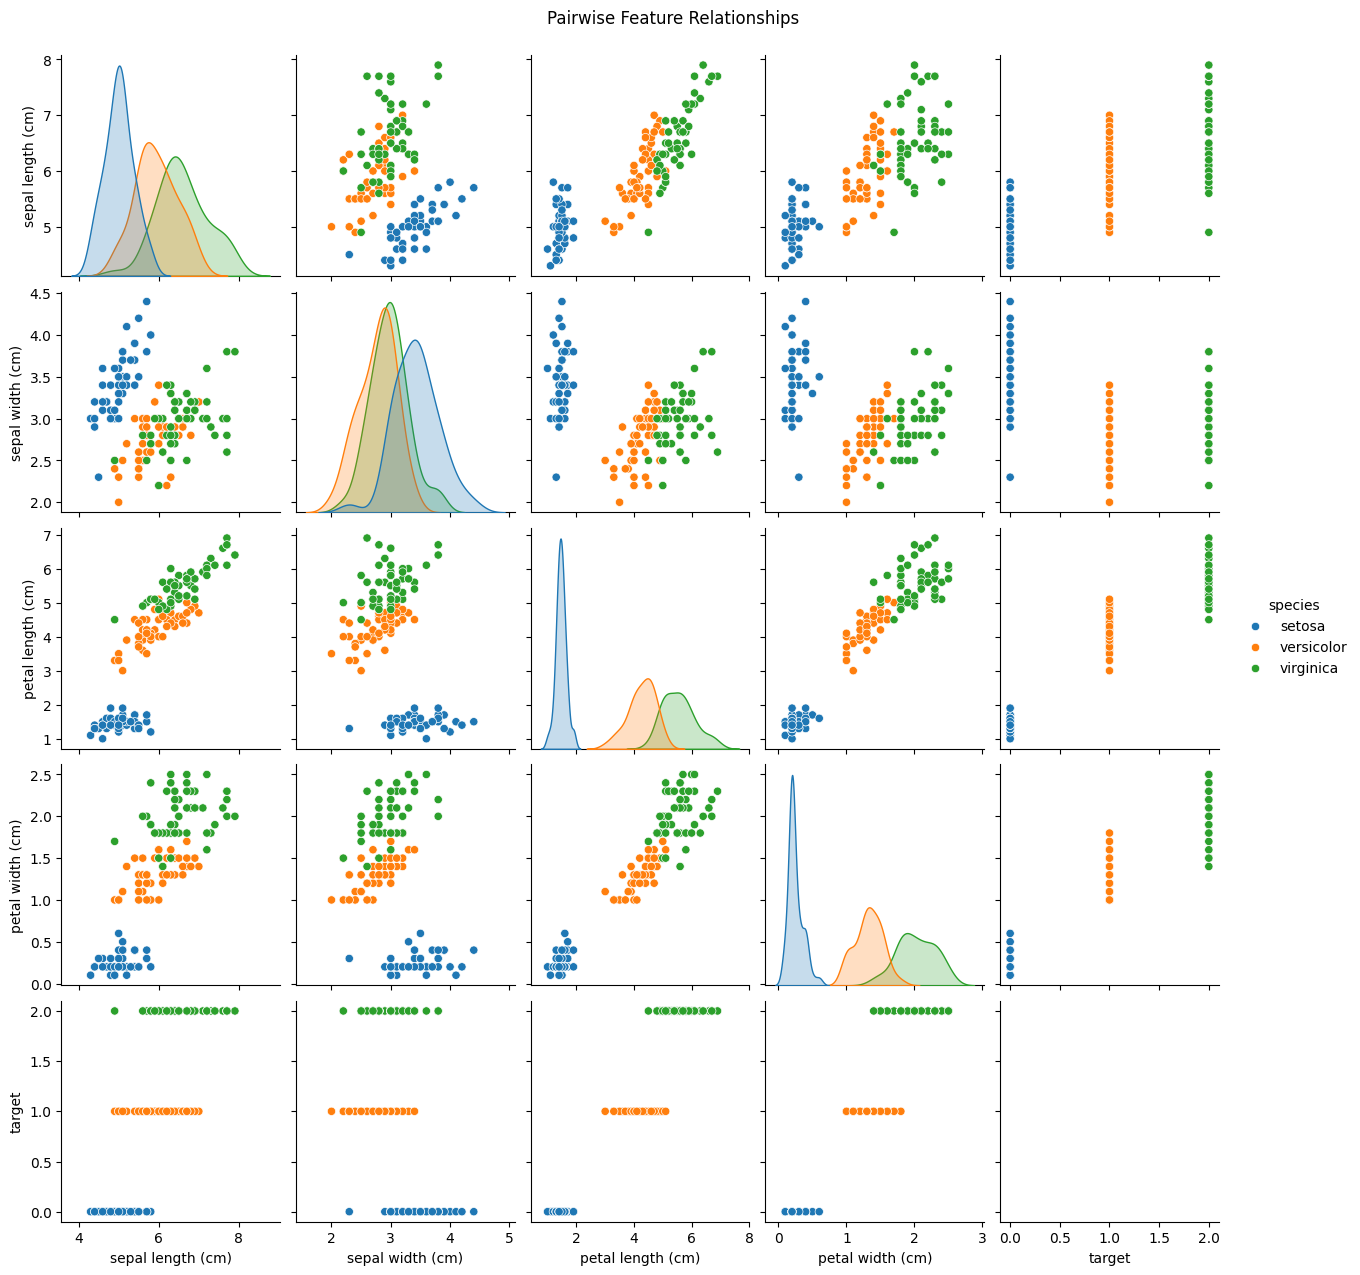

In [ ]:
# Pairplot (All Features, Colored by Species)
sns.pairplot(df, hue='species', diag_kind='kde')
plt.suptitle('Pairwise Feature Relationships', y=1.02)
plt.show()

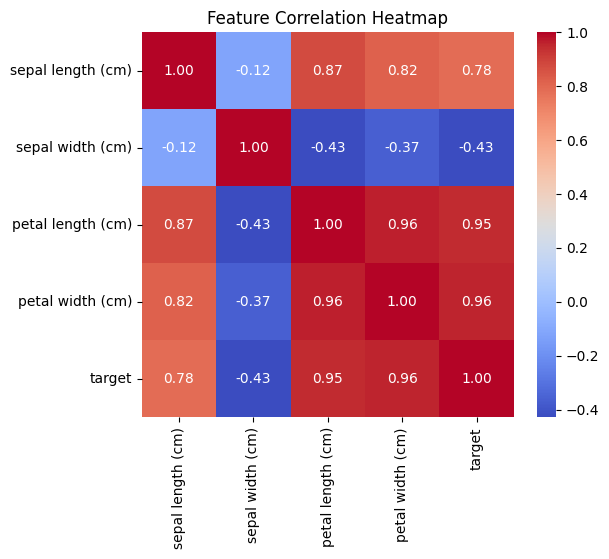

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(df.drop(columns='species').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

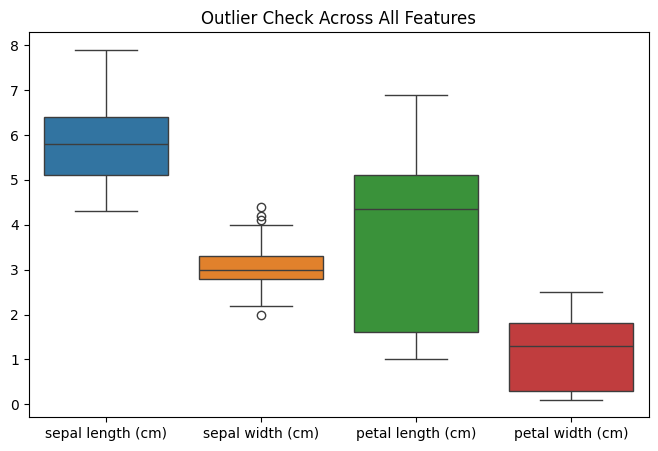

In [ ]:
# Outlier Check (All Features)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df.drop(columns=['species', 'target']))
plt.title('Outlier Check Across All Features')
plt.show()

## Visualization Summary

This section brings together all visualizations used to explore the Iris dataset visually.

- **Histograms**: Show the distribution of each individual feature across all samples.
- **Class Distribution (Countplot)**: Confirms the dataset is perfectly balanced, with 50 samples per species.
- **Boxplots by Species**: Compare the spread and median of each feature across the three species, highlighting which features separate classes best.
- **Violin Plots by Species**: Combine boxplot and density information to show both the spread and shape of each feature's distribution per species.
- **Pairplot**: Visualizes pairwise relationships between all features simultaneously, colored by species, making class separability easy to see.
- **Correlation Heatmap**: Displays the strength of relationships between features, highlighting the strong correlation between petal length and petal width.
- **Outlier Check**: A combined boxplot across all features to visually detect any potential outliers.

Overall, the visualizations confirm that **petal length and petal width** are the most discriminative features, with **setosa** being clearly separable from **versicolor** and **virginica**.

# Feature Selection

## Feature Selection Discussion: Which Features Are Most Discriminative?

Based on the visualizations (boxplots, violin plots, pairplot) and the correlation with the target class, we can rank the features:

### 🥇 Most discriminative: Petal Length & Petal Width
- Both show **clear separation** between species in the boxplots and pairplot — especially for **setosa**, which is almost perfectly isolated from the other two.
- They have the **highest correlation with the target** class (~0.95–0.96, as noted in the dataset description), meaning they change the most consistently as species changes.
- **Petal length and petal width are highly correlated with each other** (~0.96) — this means they carry overlapping (redundant) information, so a model could likely perform well using just one of them, though using both is usually still fine for small datasets like this.

### 🥈 Moderately discriminative: Sepal Length
- Shows some separation between species (setosa tends to have smaller sepal length), but with more overlap between versicolor and virginica compared to petal measurements.
- Correlation with target (~0.78) is decent but noticeably weaker than petal features.

### 🥉 Least discriminative: Sepal Width
- Shows the **most overlap** between all three species in the boxplots — the medians are close together and the distributions overlap heavily.
- Has a **negative and weak correlation** with the target (~-0.42), and even had a few outliers, as seen earlier.
- On its own, sepal width would be a poor predictor of species.

### ✅ Conclusion
If we had to select the most useful features for classification, **petal length and petal width** would be the top choice — they provide the clearest class separation with minimal overlap. **Sepal length** adds some secondary value, while **sepal width** contributes the least and could potentially be dropped without significantly hurting model performance (though with only 4 features total, it's common to just keep all of them for simplicity).

# Train/Test Split

In [ ]:
# Split the data into 80% training and 20% testing sets
# stratify=y ensures both sets maintain the same class proportions as the original dataset
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 120 samples
Testing set size: 30 samples


# Feature Scaling

In [ ]:
# Fit the scaler on training data only, then transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training Models

### Model 1: Logistic Regression

In [ ]:
# Train Logistic Regression on scaled data
log_reg = LogisticRegression(max_iter=200, random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


### Model 2: K-Nearest Neighbors

In [ ]:
# Train KNN on scaled data (important since KNN is distance-based)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

print("K-Nearest Neighbors trained successfully!")

K-Nearest Neighbors trained successfully!


### Model 3: Decision Tree

In [ ]:
# Train Decision Tree (scaling has no effect, but using scaled data for consistency)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


## Model Training Summary

Three different classifiers were trained to compare their performance on the Iris dataset:

- **Logistic Regression**: A linear model that estimates class probabilities; trained with `max_iter=200` to ensure convergence.
- **K-Nearest Neighbors (KNN)**: A distance-based model that classifies a sample based on the majority class among its `k=5` nearest neighbors.
- **Decision Tree**: A rule-based model that splits the data based on feature thresholds; naturally scale-invariant.

Before training, the features were **standardized** using `StandardScaler` (fit on the training set only, then applied to both training and test sets) since Logistic Regression and KNN are sensitive to feature scale, while Decision Tree is unaffected by it.

All models were trained using `random_state=42` (where applicable) to ensure reproducible results, using the previously created **80/20 train/test split**.

# Evaluation

### Model 1: Logistic Regression Evaluation

In [ ]:
# Predict on the test set
y_pred_log_reg = log_reg.predict(X_test_scaled)

# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log_reg))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log_reg))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_log_reg, target_names=iris.target_names))

Logistic Regression Accuracy: 0.9333333333333333

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



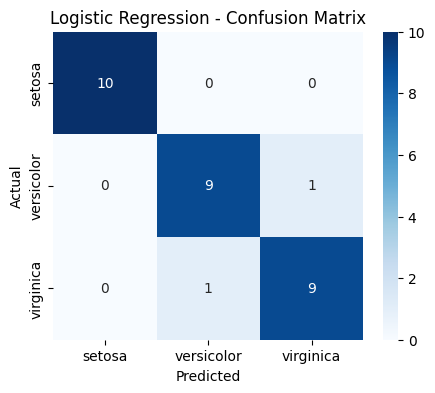

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

### Model 2: K-Nearest Neighbors Evaluation

In [ ]:
# Predict on the test set
y_pred_knn = knn.predict(X_test_scaled)

# Accuracy
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn, target_names=iris.target_names))

KNN Accuracy: 0.9333333333333333

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



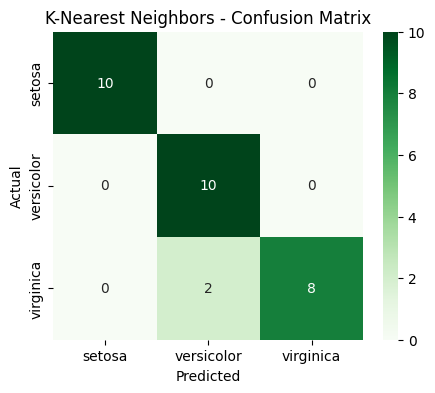

In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('K-Nearest Neighbors - Confusion Matrix')
plt.show()

### Model 3: Decision Tree Evaluation

In [ ]:
# Predict on the test set
y_pred_dt = dt.predict(X_test_scaled)

# Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, target_names=iris.target_names))

Decision Tree Accuracy: 0.9333333333333333

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



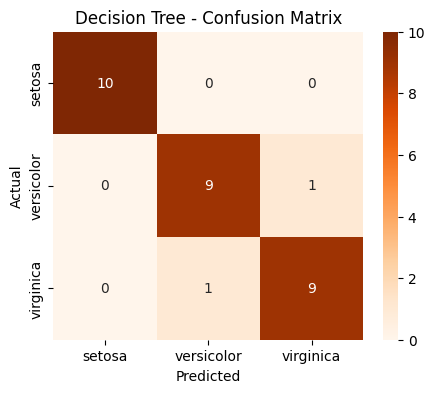

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree - Confusion Matrix')
plt.show()

## Model Evaluation

Each trained model was evaluated on the held-out test set (30 samples) using multiple metrics to assess performance:

- **Accuracy Score**: The overall percentage of correctly classified samples.
- **Confusion Matrix**: Shows the breakdown of predictions vs. actual classes, highlighting exactly which species get misclassified as which.
- **Classification Report**: Provides **precision**, **recall**, and **F1-score** for each species — giving a more detailed view of performance than accuracy alone, especially useful for checking if any class is harder to predict than others.
- **Confusion Matrix Heatmaps**: Visualized the confusion matrices for all three models (Logistic Regression, KNN, Decision Tree) to make misclassification patterns easier to spot at a glance.

As expected, **setosa** was classified with perfect accuracy across all models due to its clear separability from the other two species. Any misclassifications, if present, are expected to occur between **versicolor** and **virginica**, since these two species show some overlap in feature space (particularly in sepal measurements).

# Compare the Models

In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log_reg),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt)
    ]
})

results = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
results

,Model,Accuracy
0,Logistic Regression,0.933333
1,KNN,0.933333
2,Decision Tree,0.933333


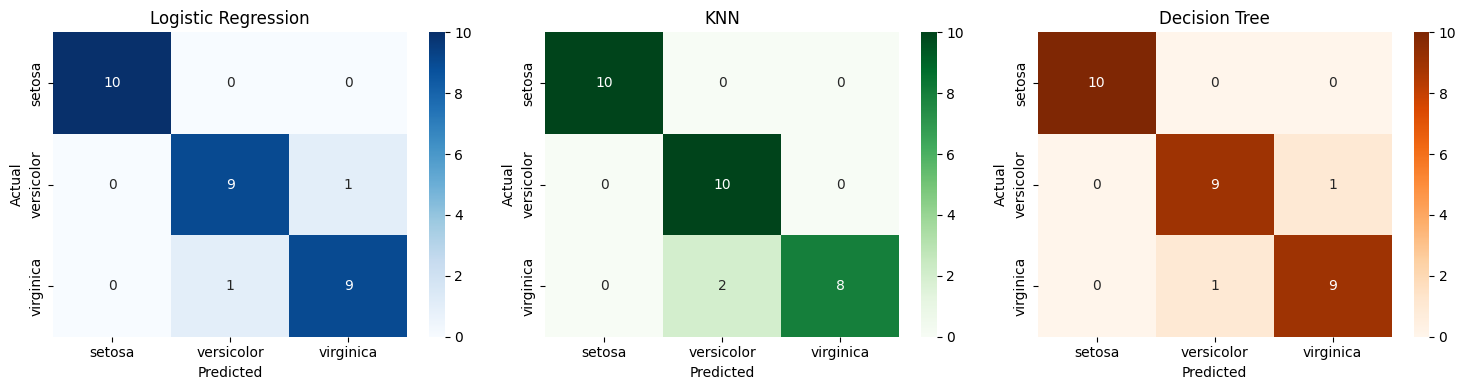

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_preds = [
    ('Logistic Regression', y_pred_log_reg, 'Blues'),
    ('KNN', y_pred_knn, 'Greens'),
    ('Decision Tree', y_pred_dt, 'Oranges')
]

for ax, (name, y_pred, cmap) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=iris.target_names, yticklabels=iris.target_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(name)

plt.tight_layout()
plt.show()

# Best performing model

## Best-Performing Model

| Model | Accuracy |
|-------|----------|
| Logistic Regression | 93.3% |
| K-Nearest Neighbors | 93.3% |
| Decision Tree | 93.3% |

**Best-performing model: Logistic Regression**

### Justification:
- All three models achieved identical overall accuracy (93.3%, 28/30 correct), so accuracy alone cannot separate them.
- Logistic Regression and Decision Tree both show **balanced, symmetric errors** (1 misclassification in each direction between versicolor and virginica).
- KNN, in contrast, shows an **asymmetric error pattern**: it misclassifies 2 virginica samples as versicolor but makes zero errors the other way, indicating a slight bias toward the versicolor class.
- Logistic Regression is chosen as the top model because it matches the best accuracy achieved, has balanced errors, and is **more interpretable and computationally simpler** than KNN (no need to store the full training set or tune `k`), making it a more practical choice for deployment.